## 1. Data Understanding & Preparation

The objective of this step is to understand the structure and quality of the Telco Customer Churn dataset before building the machine learning model.

The dataset is investigated for:
- Data structure and data types
- Missing and blank values
- Duplicate records
- Numerical and categorical features
- Target variable distribution
- Data quality issues
- Appropriate preprocessing requirements

The data is then prepared for machine learning while ensuring that preprocessing does not introduce data leakage and can be consistently applied to new customer data.

### 1.1 Load and Investigate the Dataset

The Telco Customer Churn dataset is loaded into a pandas DataFrame. The initial records, dataset dimensions, column names, and data types are examined to understand the available customer attributes.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/TelcoCustomerChurn.csv")

# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Number of rows and columns
print("Dataset shape:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Dataset information
df.info()

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity   

**Observation:**

The dataset contains 7,043 customer records and 21 columns. The attributes include customer demographics, subscribed services, contract details, billing information, and the `Churn` target variable.

Most service and demographic attributes are categorical. `tenure`, `MonthlyCharges`, and `TotalCharges` represent numerical customer information. However, `TotalCharges` is initially stored as an object data type and requires further investigation and cleaning.

### 1.2 Data Type Check

The data types of all columns are checked to identify whether each attribute has been loaded with an appropriate data type.

Correct data types are important because numerical and categorical variables require different preprocessing techniques before they can be used for machine learning.

In [3]:
data_type_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values
})

data_type_summary

,Column,Data Type,Unique Values
0,customerID,str,7043
1,gender,str,2
2,SeniorCitizen,int64,2
3,Partner,str,2
4,Dependents,str,2
5,tenure,int64,73
6,PhoneService,str,2
7,MultipleLines,str,3
8,InternetService,str,3
9,OnlineSecurity,str,3


**Observation:**

Most categorical variables are correctly identified as object/str values. Numerical variables such as `SeniorCitizen`, `tenure`, and `MonthlyCharges` are stored as numerical types.

`TotalCharges` is stored as an object even though it represents a numerical value. This is caused by blank/whitespace values in the column. The column will therefore be converted to a numeric type during data cleaning.

### 1.3 Missing Value Analysis

Missing values are checked to determine whether any customer records contain incomplete information.

Both standard null values and blank/whitespace values are investigated because blank strings may not be detected by the standard `isnull()` check.

In [4]:
# Standard missing value check
missing_values = df.isnull().sum()

print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# Check blank/whitespace values in object columns
blank_values = {}

for column in df.select_dtypes(include="object").columns:
    blank_count = df[column].astype(str).str.strip().eq("").sum()
    if blank_count > 0:
        blank_values[column] = blank_count

print("Blank/whitespace values:")
print(blank_values)

Blank/whitespace values:
{'TotalCharges': np.int64(11)}


/var/folders/hk/kxlkv08d5hj1k90c9rk62f940000gp/T/ipykernel_26796/524442863.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object").columns:


**Observation:**

The standard null-value check does not identify missing values in the dataset. However, further inspection identifies 11 blank/whitespace values in the `TotalCharges` column.

Since `TotalCharges` is a numerical feature, these blank values need to be handled before model training.

### 1.4 Data Cleaning

The `TotalCharges` column is converted from object to numeric using `pd.to_numeric()`. Invalid or blank values are converted to missing values during this process.

The 11 resulting missing values are replaced with 0. These records correspond to customers with zero tenure, where no accumulated total charges have been recorded.

This approach allows the affected customer records to be retained instead of unnecessarily removing them from the dataset.

In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print(df["TotalCharges"].isnull().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(0)
print(df["TotalCharges"].isnull().sum())
print(df["TotalCharges"].dtype)

11
0
float64


### 1.5 Duplicate Analysis

Duplicate records are checked to ensure that the same customer information has not been included multiple times.

Duplicate `customerID` values are also checked because each customer should have a unique identifier.

In [7]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

duplicate_customer_ids = df["customerID"].duplicated().sum()

print("Duplicate customer IDs:", duplicate_customer_ids)

Duplicate rows: 0
Duplicate customer IDs: 0


**Observation:**

No duplicate rows were identified in the dataset. There are also no duplicate customer IDs.

Therefore, no records need to be removed due to duplication.

### 1.6 Numerical and Categorical Feature Identification

The features are divided into numerical and categorical variables because they require different preprocessing approaches.

The numerical features represent measurable customer characteristics, while categorical features represent customer attributes or service selections.

In [8]:
# Numerical and categorical feature identification
numerical_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print("Numerical features:")
print(numerical_features)

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

print("Categorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Numerical Features:**

- `SeniorCitizen`
- `tenure`
- `MonthlyCharges`
- `TotalCharges`

**Categorical Features:**

- `gender`
- `Partner`
- `Dependents`
- `PhoneService`
- `MultipleLines`
- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `StreamingTV`
- `StreamingMovies`
- `Contract`
- `PaperlessBilling`
- `PaymentMethod`

`customerID` is treated as an identifier and is excluded from the predictive features.

### 1.7 Target Variable Analysis

The target variable for this project is `Churn`, which indicates whether a customer has left the telecom service.

The distribution of the target classes is examined to understand whether the dataset is balanced or imbalanced.

In [9]:
id_column = "customerID"
target = "Churn"
print(df["Churn"].value_counts())
churn_distribution = df["Churn"].value_counts(normalize=True) * 100

print(churn_distribution.round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


### 1.8 Target Encoding

The `Churn` target variable is converted from categorical values into binary numerical values so that it can be used by the classification model.

The encoding used is:

- `No` → `0`
- `Yes` → `1`

A value of 1 therefore represents a customer who churned.

In [10]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

**Observation:**

The dataset contains 5,174 customers who did not churn and 1,869 customers who churned.

Approximately 73.5% of customers have not churned, while approximately 26.5% have churned.

Therefore, the target variable is moderately imbalanced, with non-churn customers representing the majority class. This will be considered when evaluating the classification model, particularly when interpreting Precision, Recall, and F1 Score.

### 1.9 Removing Customer ID

The `customerID` column is excluded from the predictive features.

Although it uniquely identifies each customer, it does not contain meaningful information about customer behaviour or service usage. Including the identifier could allow the model to learn meaningless patterns that would not generalize to new customers.

Therefore, `customerID` is retained only as an identifier and is not used for model training.

In [11]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

### 1.10 Train/Test Split

The dataset is divided into training and testing subsets using a 70:30 split as specified in the assignment.

A `random_state` of 42 is used to make the split reproducible.

Stratification is applied using the target variable so that the proportion of churned and non-churned customers remains approximately consistent in both the training and testing datasets.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (4930, 19)
Testing set: (2113, 19)


**Observation:**

The dataset is divided into approximately 70% training data and 30% testing data. Stratification helps maintain the original churn class distribution in both subsets.

### 1.11 Preprocessing and Data Leakage Prevention

To avoid data leakage, preprocessing steps such as categorical encoding and numerical transformations should not be fitted using the complete dataset before the train/test split.

A Scikit-learn `Pipeline` and `ColumnTransformer` will be used for the final model.

The preprocessing workflow will be:

1. Split the data into training and testing sets.
2. Fit the preprocessing transformations only on the training data.
3. Transform the training data using the fitted transformations.
4. Apply the same fitted transformations to the test data.
5. Use the same complete pipeline when making predictions for new customers.

Categorical variables will be encoded using `OneHotEncoder`.

Keeping preprocessing and the Decision Tree model in a single pipeline ensures that the same transformations are consistently applied during model training, evaluation, and API predictions.

### 1.12 Data Preparation Summary

The dataset was investigated and prepared for the machine learning workflow.

Key observations and decisions are summarized below:

- The dataset contains 7,043 customer records and 21 columns.
- No duplicate rows or duplicate customer IDs were found.
- `TotalCharges` was initially stored as an object instead of a numerical type.
- 11 whitespace values were identified in `TotalCharges` and were converted to missing values.
- The missing `TotalCharges` values were replaced with 0 because they correspond to customers with zero tenure.
- The dataset contains both numerical and categorical features.
- `customerID` was excluded from model training because it is an identifier rather than a predictive customer attribute.
- The target variable `Churn` was encoded as `0 = No` and `1 = Yes`.
- Approximately 26.5% of customers have churned, indicating moderate class imbalance.
- The dataset was split into training and testing sets using a 70:30 ratio.
- `random_state=42` was used to ensure reproducibility.
- Stratification was applied to preserve the target class distribution across the training and testing sets.
- A Scikit-learn `Pipeline` and `ColumnTransformer` will be used for preprocessing and modelling to prevent data leakage and ensure consistent processing of unseen customer data.

The prepared dataset is now ready for exploratory data analysis.

## 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand customer characteristics and identify patterns associated with customer churn.

The analysis focuses on:
- Overall churn distribution
- Customer contract characteristics
- Internet service characteristics
- Customer tenure
- Monthly charges
- Payment methods
- Relationships between numerical variables

For categorical variables, churn rate is used where appropriate instead of only customer counts, as this provides a more meaningful comparison of churn behaviour across customer groups.

### 2.1 Churn Distribution

The first step is to understand the distribution of the target variable, `Churn`.

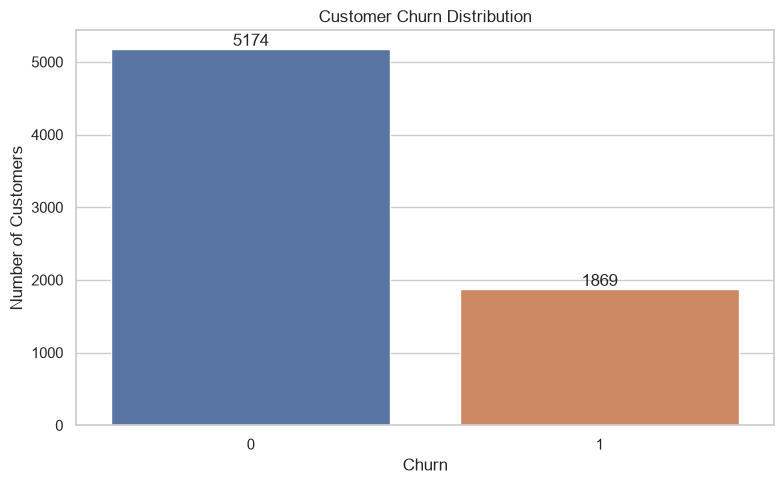

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    legend=False
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

**Business Insight:**

The majority of customers have not churned, while approximately 26.5% of customers have churned. This indicates that the target variable is moderately imbalanced.

Because churned customers represent a smaller proportion of the dataset, accuracy alone may not provide a complete picture of model performance. Precision, recall, and F1 Score will also be considered during model evaluation.

### 2.2 Churn Rate by Contract Type

Contract duration may influence customer retention. Therefore, churn rates are compared across different contract types.

In [14]:
print(df["Churn"].unique())
print(df["Churn"].value_counts())

[0 1]
Churn
0    5174
1    1869
Name: count, dtype: int64


         Contract  ChurnRate
0  Month-to-month  42.709677
1        One year  11.269518
2        Two year   2.831858


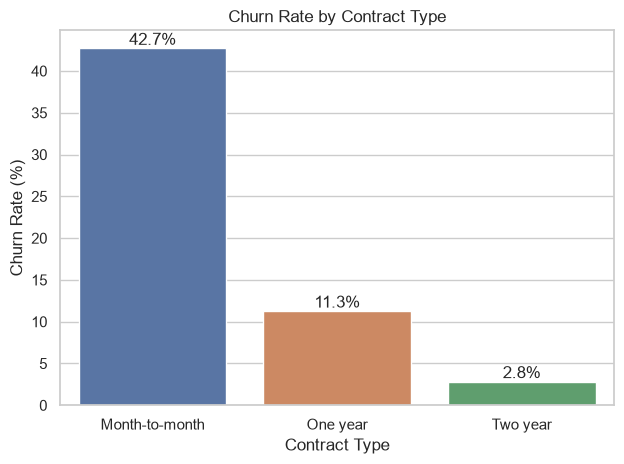

In [15]:
# Calculate churn rate for each contract type
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == 1).mean() * 100)
    .reset_index(name="ChurnRate")
)

contract_churn = contract_churn.sort_values(
    "ChurnRate",
    ascending=False
)

print(contract_churn)

ax = sns.barplot(
    data=contract_churn,
    x="Contract",
    y="ChurnRate",
    hue="Contract",
    legend=False
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

**Business Insight:**

Customers with month-to-month contracts have a substantially higher churn rate than customers with one-year or two-year contracts.

This suggests that customers with shorter contractual commitments may be more likely to leave the company. The retention team could therefore focus on month-to-month customers and consider incentives for longer-term contracts.

### 2.3 Churn Rate by Internet Service

Internet service type is analysed to determine whether churn behaviour differs across service categories.

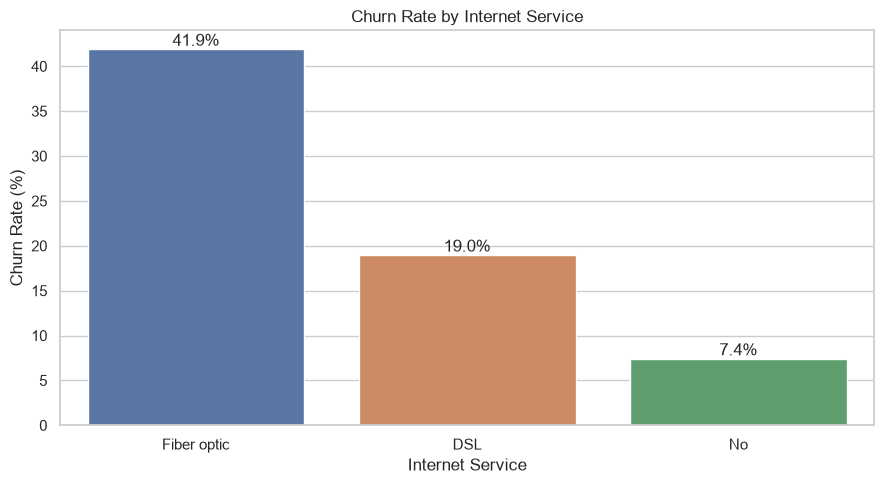

In [16]:
# Calculate churn rate by internet service
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == 1).mean() * 100)
    .reset_index(name="ChurnRate")
)

internet_churn = internet_churn.sort_values(
    "ChurnRate",
    ascending=False
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=internet_churn,
    x="InternetService",
    y="ChurnRate",
    hue="InternetService",
    legend=False
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

**Business Insight:**

The churn rate differs considerably across internet service types. Fiber optic customers show a higher churn rate compared with DSL customers, while customers without internet service have a lower churn rate.

This relationship may indicate differences in pricing, service experience, competition, or customer expectations. Further investigation would be required before concluding that the service type itself causes churn.

### 2.4 Churn Rate by Customer Tenure

Customer tenure represents the number of months a customer has been with the company. Tenure is grouped into meaningful intervals to understand how churn behaviour changes as the customer relationship matures.

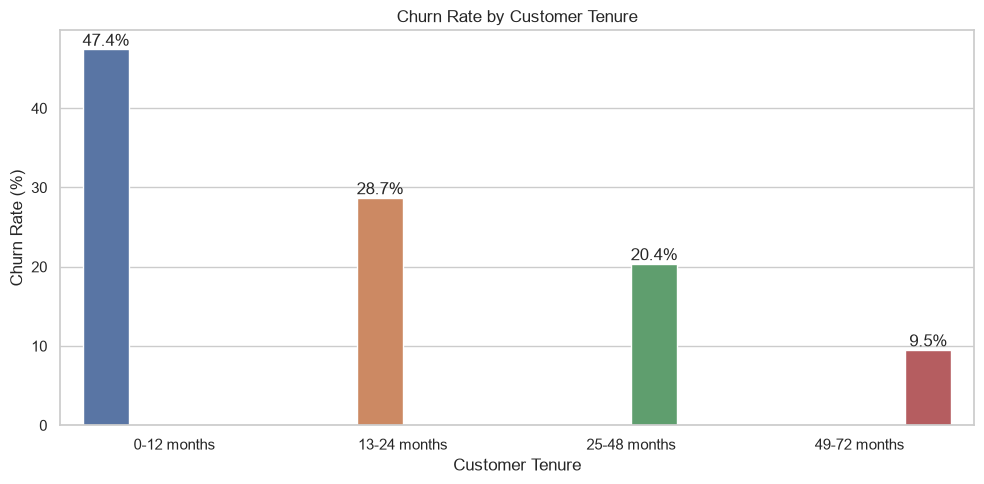

In [17]:
# Create tenure groups for EDA
tenure_bins = [0, 12, 24, 48, 72]

tenure_labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

# Calculate churn rate
tenure_churn = (
    df.groupby("TenureGroup", observed=False)["Churn"]
    .apply(lambda x: (x == 1).mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=tenure_churn,
    x="TenureGroup",
    y="ChurnRate",
    hue="TenureGroup",
    legend=False
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

**Business Insight:**

Customers with shorter tenure have a significantly higher churn rate than long-term customers. The first 12 months represent a particularly high-risk period.

This suggests that customer onboarding and early-stage engagement may be important retention opportunities. The company could consider targeted communication or offers during the early stages of the customer relationship.

### 2.5 Monthly Charges by Churn Status

Monthly charges are analysed to determine whether customers who churn have a different charge distribution compared with customers who remain with the company.

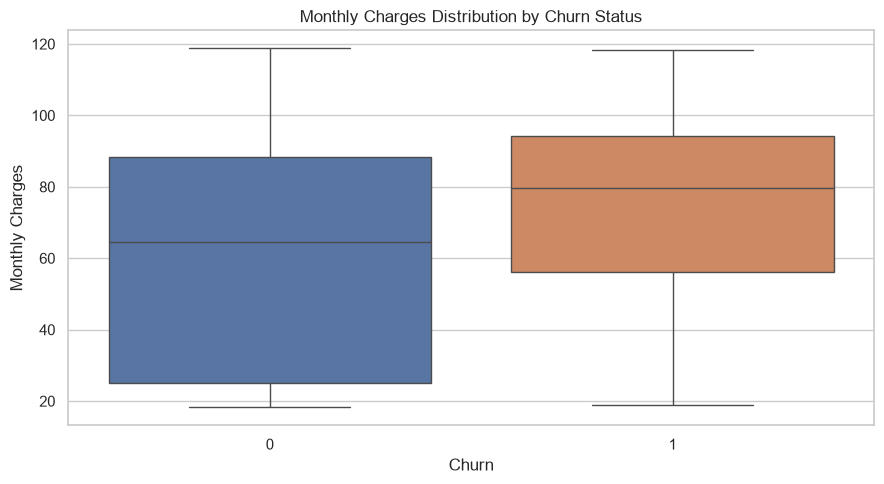

In [18]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    legend=False
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

**Business Insight:**

Churned customers generally have higher monthly charges than customers who remain with the company.

This indicates that monthly charges may be associated with churn behaviour. Higher charges could potentially increase customer sensitivity to pricing or perceived value, making this variable useful for churn prediction.

### 2.6 Churn Rate by Payment Method

Payment method is analysed to determine whether customers using different payment methods show different churn behaviour.

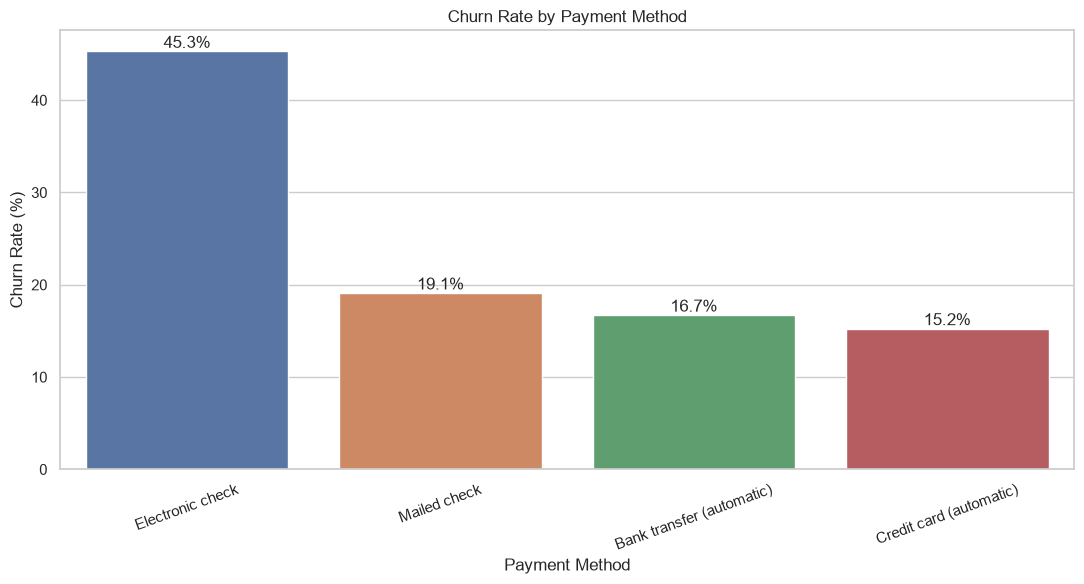

In [19]:
# Calculate churn rate by payment method
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == 1).mean() * 100)
    .reset_index(name="ChurnRate")
)

payment_churn = payment_churn.sort_values(
    "ChurnRate",
    ascending=False
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="ChurnRate",
    hue="PaymentMethod",
    legend=False
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

**Business Insight:**

Customers using electronic check have a substantially higher churn rate compared with customers using other payment methods.

This could indicate differences in payment convenience or customer engagement. The company could investigate whether encouraging automatic payment methods is associated with improved customer retention.

### 2.7 Relationship Between Tenure and Monthly Charges

A scatter plot is used to examine the relationship between customer tenure and monthly charges while distinguishing between customers who churned and those who did not.

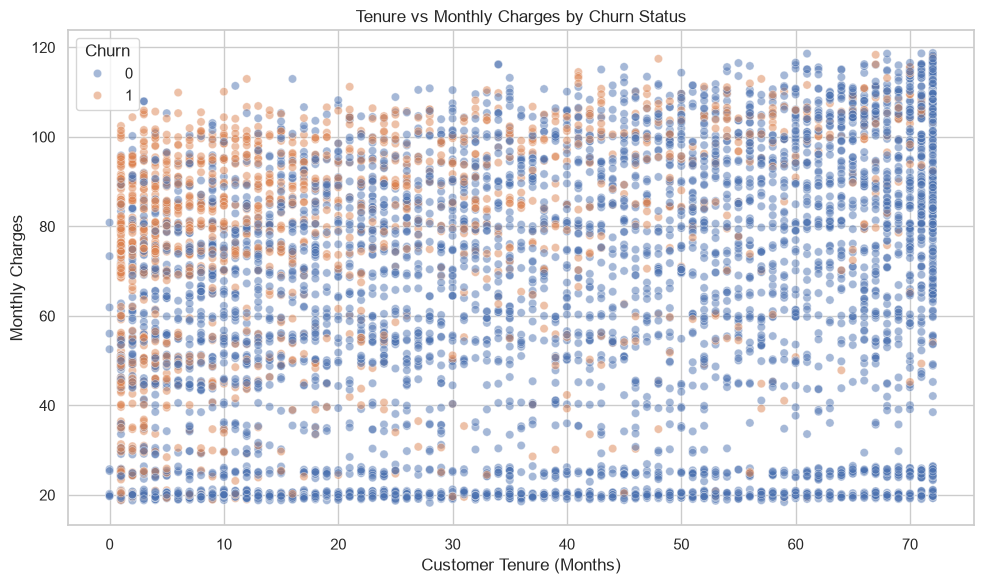

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.5
)

plt.title("Tenure vs Monthly Charges by Churn Status")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [21]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup']


**Business Insight:**

The scatter plot shows that churned customers are more concentrated among customers with shorter tenure and relatively higher monthly charges.

This supports the earlier EDA findings that both customer tenure and monthly charges may be useful predictors of churn. However, the relationship is not completely separable, which indicates that multiple customer characteristics will likely be required to predict churn effectively.

### 2.8 EDA Summary

The exploratory analysis identified several customer characteristics that are associated with churn:

1. **Contract Type:** Month-to-month customers have a substantially higher churn rate than customers with longer-term contracts.

2. **Tenure:** Customers with shorter tenure are more likely to churn, with the first year representing a particularly high-risk period.

3. **Internet Service:** Fiber optic customers show a higher churn rate than DSL and customers without internet service.

4. **Monthly Charges:** Churned customers generally have higher monthly charges.

5. **Payment Method:** Electronic-check customers have a higher churn rate compared with customers using other payment methods.

6. **Numerical Relationships:** The relationship between tenure, monthly charges, and churn suggests that multiple customer characteristics may contribute to churn behaviour.

These findings provide useful business context for the predictive modelling stage. However, the EDA findings represent associations and do not establish causal relationships.

The identified patterns will also be considered when creating additional features for the machine learning model.

## 3. Feature Engineering


Feature engineering involves creating new variables from the existing dataset that may help the machine learning model identify patterns related to customer churn.

Two meaningful features were created:

1. **TenureGroup** – groups customers based on how long they have been with the company.
2. **AvgMonthlySpend** – estimates the customer's average monthly spending based on their total charges and tenure.

These features were selected because customer tenure and spending behaviour can provide additional information about churn risk.

In [22]:
df_fe = df.copy()

# Convert TotalCharges to numeric
df_fe["TotalCharges"] = pd.to_numeric(
    df_fe["TotalCharges"],
    errors="coerce"
)

# Fill missing TotalCharges
df_fe["TotalCharges"] = df_fe["TotalCharges"].fillna(0)

# Feature 1: Tenure Group
df_fe["TenureGroup"] = pd.cut(
    df_fe["tenure"],
    bins=[-1, 12, 24, 48, float("inf")],
    labels=[
        "0-1 Year",
        "1-2 Years",
        "2-4 Years",
        "4+ Years"
    ]
)

# Feature 2: Average Monthly Spend
df_fe["AvgMonthlySpend"] = (
    df_fe["TotalCharges"] /
    df_fe["tenure"].replace(0, 1)
)

print(df_fe[[
    "tenure",
    "TenureGroup",
    "TotalCharges",
    "AvgMonthlySpend"
]].head())

   tenure TenureGroup  TotalCharges  AvgMonthlySpend
0       1    0-1 Year         29.85        29.850000
1      34   2-4 Years       1889.50        55.573529
2       2    0-1 Year        108.15        54.075000
3      45   2-4 Years       1840.75        40.905556
4       2    0-1 Year        151.65        75.825000


In [23]:
print(
    df_fe.groupby("TenureGroup", observed=True)["Churn"]
    .value_counts(normalize=True)
    .unstack()
)
print(
    df_fe.groupby("Churn")["AvgMonthlySpend"]
    .mean()
)

print(df_fe.shape)

print(df_fe[[
    "tenure",
    "TenureGroup",
    "TotalCharges",
    "AvgMonthlySpend",
    "Churn"
]].head())

Churn               0         1
TenureGroup                    
0-1 Year     0.525618  0.474382
1-2 Years    0.712891  0.287109
2-4 Years    0.796110  0.203890
4+ Years     0.904868  0.095132
Churn
0    61.181674
1    74.433154
Name: AvgMonthlySpend, dtype: float64
(7043, 23)
   tenure TenureGroup  TotalCharges  AvgMonthlySpend  Churn
0       1    0-1 Year         29.85        29.850000      0
1      34   2-4 Years       1889.50        55.573529      0
2       2    0-1 Year        108.15        54.075000      1
3      45   2-4 Years       1840.75        40.905556      0
4       2    0-1 Year        151.65        75.825000      1


### Feature Engineering Summary

Two additional features were created: `TenureGroup` and `AvgMonthlySpend`.

`TenureGroup` captures differences in customer behaviour based on the length of their relationship with the company, while `AvgMonthlySpend` provides a normalized measure of customer spending.

Both features may provide additional information to the churn prediction model beyond the original variables.

## 4. Model Development

A Decision Tree Classifier is used to predict customer churn.

Two different Decision Tree configurations are trained and compared:

- Model 1: A less complex tree with a maximum depth of 4.
- Model 2: A more complex tree with a maximum depth of 8.

The models are compared using Accuracy, Precision, Recall, and F1 Score. The final model is selected based on its ability to identify customers who are likely to churn while maintaining reasonable overall performance.

In [24]:
X = df_fe.drop(columns=["Churn", "customerID"])
y = df_fe["Churn"]

print(X.columns.tolist())
print("Features:", X.shape)
print("Target:", y.shape)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'AvgMonthlySpend']
Features: (7043, 21)
Target: (7043,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

/var/folders/hk/kxlkv08d5hj1k90c9rk62f940000gp/T/ipykernel_26796/313462028.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

dt_model_1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=4,
                min_samples_split=20,
                min_samples_leaf=10,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

dt_model_1.fit(X_train, y_train)
y_pred_dt1 = dt_model_1.predict(X_test)

print("Model 1 trained successfully")


Model 1 trained successfully


In [28]:
dt_model_2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

dt_model_2.fit(X_train, y_train)
y_pred_dt2 = dt_model_2.predict(X_test)
print("Model 2 trained successfully")

Model 2 trained successfully


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

dt_results = pd.DataFrame({
    "Model": [
        "Decision Tree - Depth 4",
        "Decision Tree - Depth 8"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt1),
        accuracy_score(y_test, y_pred_dt2)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt1),
        precision_score(y_test, y_pred_dt2)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt1),
        recall_score(y_test, y_pred_dt2)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_dt1),
        f1_score(y_test, y_pred_dt2)
    ]
})

dt_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree - Depth 4,0.733144,0.498305,0.786096,0.609959
1,Decision Tree - Depth 8,0.732434,0.497409,0.770053,0.604407


### 5. Model Selection

Two Decision Tree configurations were tested using different tree depths.

The Depth 4 model performed slightly better than the Depth 8 model across Accuracy, Precision, Recall, and F1 Score.

The Depth 4 model was selected as the final model because it provides better overall performance while keeping the tree simpler and easier to interpret.

In [30]:
final_model = dt_model_1

y_pred = final_model.predict(X_test)

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.7331
Precision: 0.4983
Recall   : 0.7861
F1 Score : 0.61


In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[739 296]
 [ 80 294]]


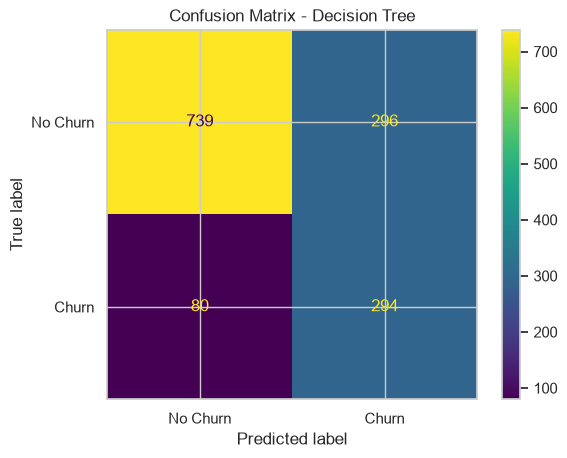

In [33]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Confusion Matrix - Decision Tree")
plt.show()

### Business Interpretation

The final Decision Tree correctly identifies a large proportion of customers who are likely to churn, as shown by the Recall of approximately 78.6%.

The Precision of approximately 49.8% means that not all customers predicted as churners will actually churn. This may result in some additional retention efforts being targeted at customers who would have stayed.

However, identifying actual churn customers is important because missing a customer who is likely to leave can result in lost revenue and a missed retention opportunity.

Therefore, the model provides a useful starting point for identifying customers who may require retention actions.

### Precision vs Recall for Churn Prediction

For telecom churn prediction, Recall should generally be given higher priority.

Recall measures how many of the actual churn customers are correctly identified by the model.

A false negative means that a customer who is going to churn was not identified. This can result in a missed opportunity to offer incentives, improve customer service, or take other retention actions.

Although a higher Recall can result in some false positives, the cost of contacting

### 6. Model Interpretation

In [34]:
tree = final_model.named_steps["classifier"]

preprocessor_fitted = final_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

importances = tree.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)



,Feature,Importance
21,cat__Contract_Two year,0.431509
20,cat__Contract_One year,0.269861
6,cat__InternetService_Fiber optic,0.118781
30,remainder__tenure,0.099275
19,cat__StreamingMovies_Yes,0.036310
32,remainder__TotalCharges,0.014631
31,remainder__MonthlyCharges,0.009721
33,remainder__AvgMonthlySpend,0.009178
24,cat__PaymentMethod_Electronic check,0.008730
4,cat__MultipleLines_No phone service,0.002004


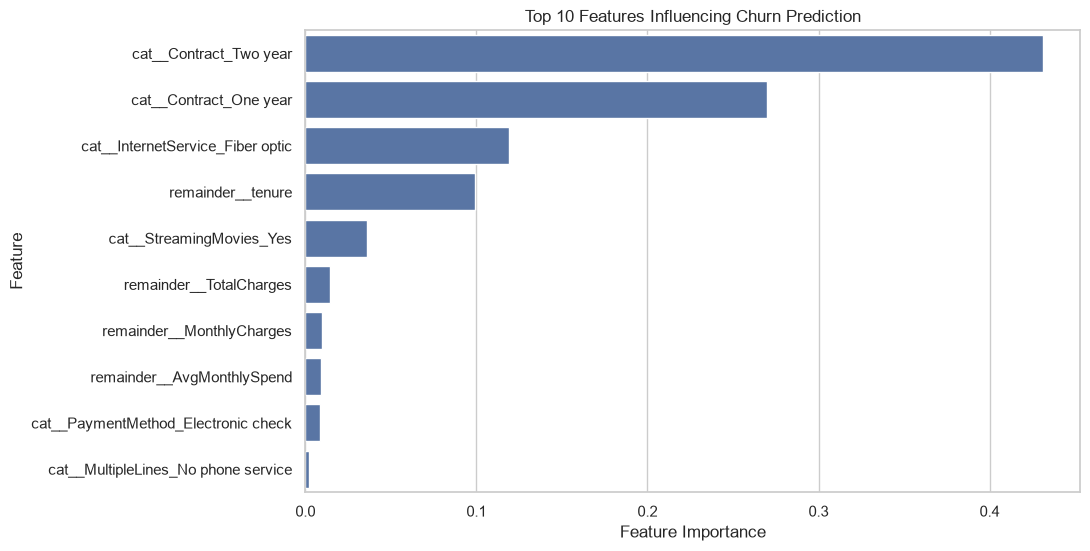

In [35]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Influencing Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

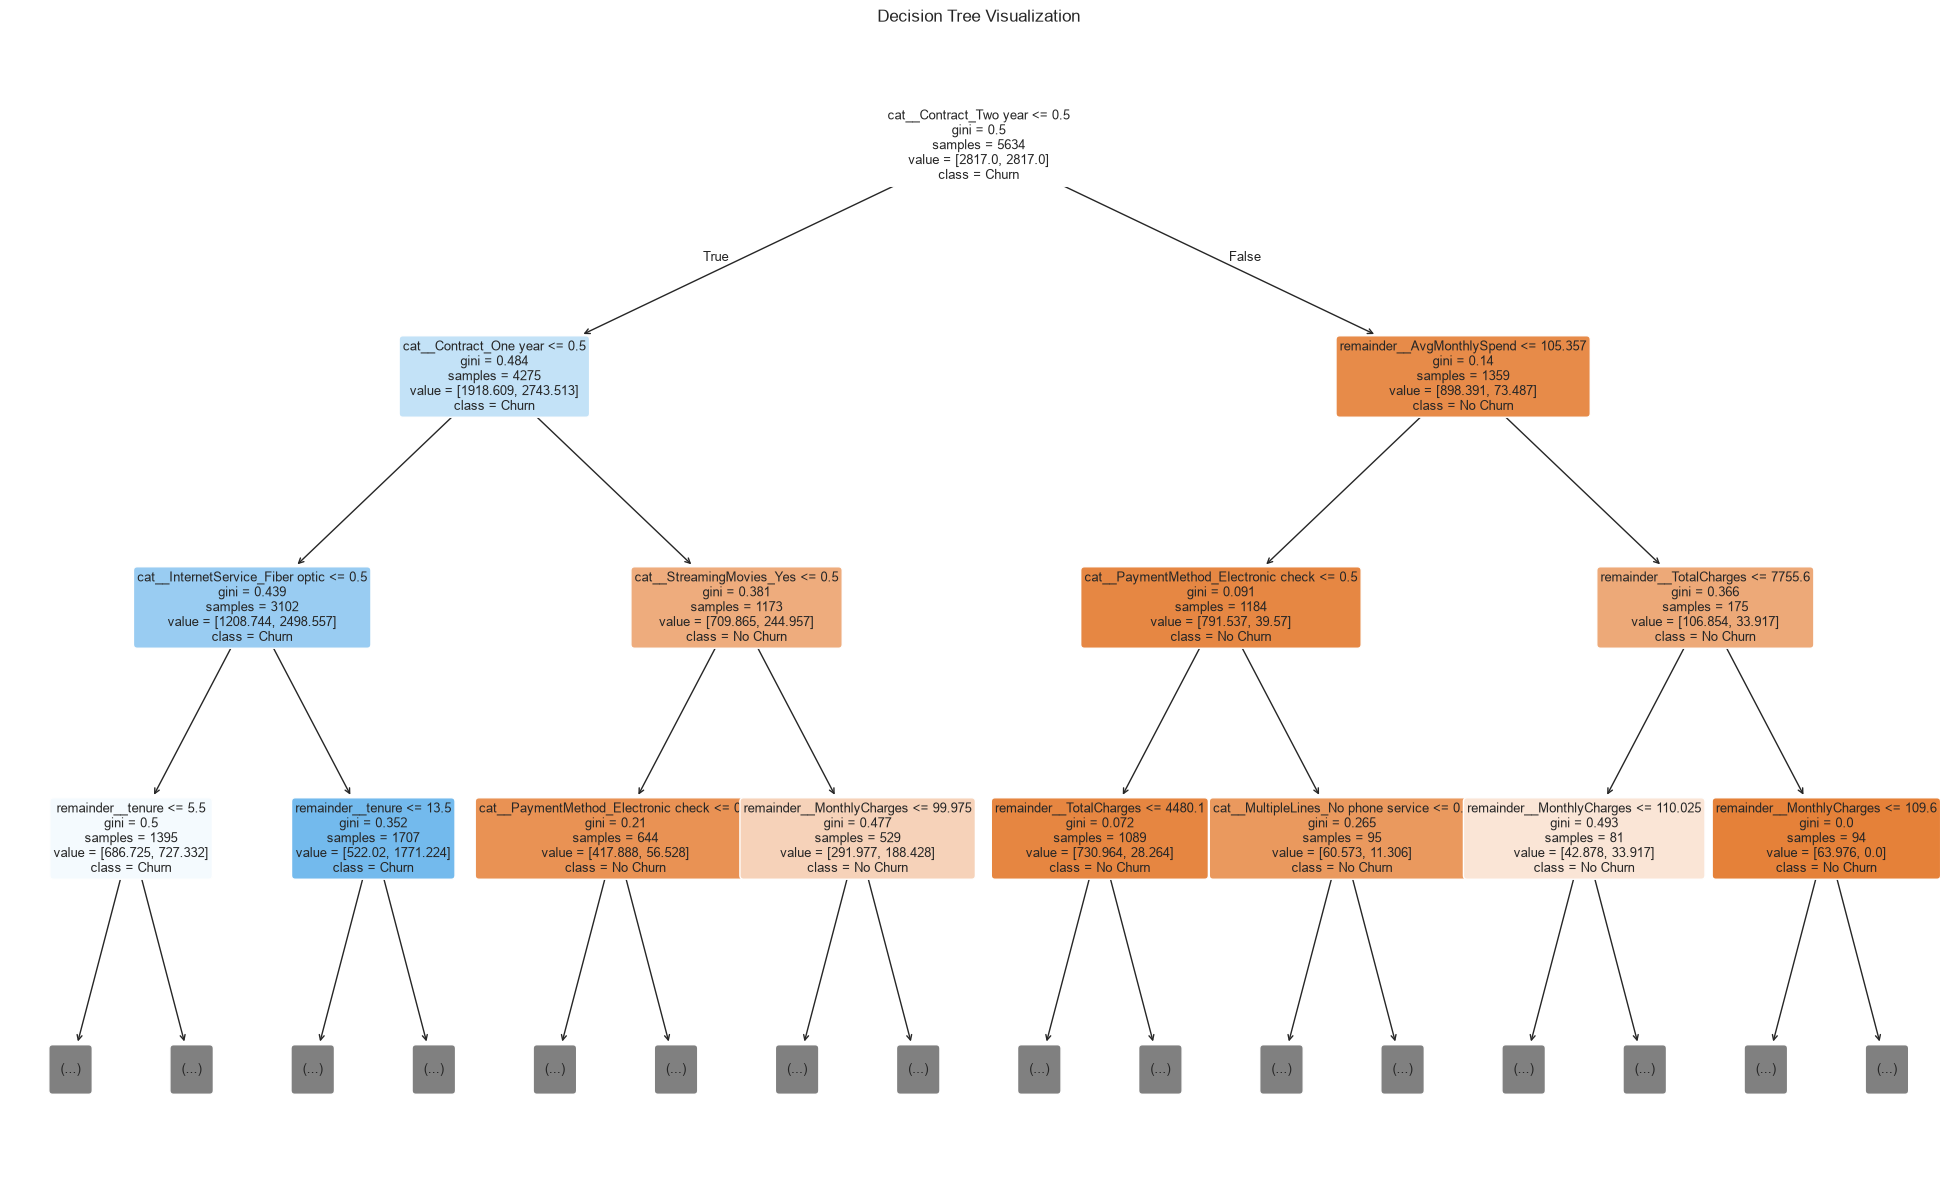

In [36]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree Visualization")
plt.show()

### 7. Model saving and API

In [38]:
import joblib

# Save the complete pipeline
joblib.dump(final_model, "../model/churn_model.pkl")

print("Model saved successfully as churn_model.pkl")

Model saved successfully as churn_model.pkl
